 ##  Section 0. Présentation du modèle : Random Forest
** Introduction**

La Random Forest est une méthode d’apprentissage supervisé appartenant aux techniques d’ensemble (ensemble learning), utilisée pour des tâches de classification et de régression. Elle repose sur la construction d’un ensemble d’arbres de décision entraînés sur des sous-échantillons des données, dont les prédictions sont agrégées afin d’améliorer la performance globale.

**Principe du modèle**

Le modèle Random Forest combine deux idées fondamentales :

Le bootstrap (rééchantillonnage avec remise) permettant de générer plusieurs jeux de données d’entraînement
Le bagging (Bootstrap Aggregating) consistant à entraîner plusieurs modèles indépendants et à agréger leurs prédictions

Chaque arbre est construit selon l’algorithme CART, qui effectue des divisions binaires successives en minimisant une mesure d’impureté (indice de Gini).

Une randomisation supplémentaire est introduite lors de la sélection des variables à chaque split, ce qui permet de réduire la corrélation entre les arbres et d’améliorer la généralisation du modèle.

**Hypothèses**

Contrairement aux modèles paramétriques, Random Forest :

ne suppose aucune relation linéaire entre les variables
est robuste aux données bruitées et aux interactions complexes
nécessite peu de prétraitement des données

Cependant, il suppose implicitement que :

les observations sont indépendantes
les données sont représentatives du phénomène étudié
**Métriques d’évaluation**

Dans ce projet, les performances des modèles sont évaluées à l’aide des métriques suivantes :

Accuracy : proportion de prédictions correctes
Précision (Precision) : proportion de prédictions positives correctes
Rappel (Recall) : capacité à détecter les vrais positifs
F1-score : moyenne harmonique entre précision et rappel

Pour Random Forest, une métrique supplémentaire est utilisée :

OOB score (Out-Of-Bag) : estimation interne de la performance basée sur les observations non utilisées lors du bootstrap

**Hyperparamètres retenus**

Les principaux hyperparamètres étudiés dans ce projet sont :

n_estimators : nombre d’arbres dans la forêt
max_depth : profondeur maximale des arbres
max_features : nombre de variables considérées à chaque split
oob_score : activation de l’évaluation Out-Of-Bag

Ces hyperparamètres influencent directement le compromis biais/variance ainsi que la performance globale du modèle.

**Objectif de l’étude**

L’objectif de ce travail est d’évaluer les performances du modèle Random Forest sur le dataset Pima Indians Diabetes, et de le comparer à d’autres modèles tels que l’arbre de décision, la régression logistique et le Naive Bayes.



## Section 1  _  Chargement et prétraitement de données

In [ ]:
import numpy as np
import pandas as pd

url = "https://raw.githubusercontent.com/plotly/datasets/refs/heads/master/diabetes.csv"
df = pd.read_csv(url)
df.head(15)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


### 🔍 Interprétation du prétraitement des données

Les variables *Glucose, BloodPressure, SkinThickness, Insulin* et *BMI* représentent des mesures physiologiques qui ne peuvent pas être égales à zéro chez une personne vivante.

Ainsi, les valeurs égales à 0 dans ces colonnes sont considérées comme des données manquantes ou des erreurs de saisie. Ces valeurs ont donc été remplacées par des statistiques appropriées (comme la médiane) afin d’améliorer la qualité des données et la performance des modèles.

In [ ]:
print('les différentes variables et leurs types:\n')
print(df.dtypes)

les différentes variables et leurs types:

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


### 🔍 Interprétation des variables du dataset

Le dataset ne contient pas de variables catégorielles nécessitant un encodage (comme One-Hot Encoding ou Label Encoding). Toutes les variables sont déjà numériques et directement exploitables par les modèles de machine learning.

Ces variables représentent des mesures médicales réelles :

- Age : âge du patient  
- Glucose : taux de glucose dans le sang  
- BMI : indice de masse corporelle  
- Pregnancies : nombre de grossesses  
- BloodPressure : pression artérielle  
- SkinThickness : épaisseur de la peau  
- Insulin : taux d’insuline  
- DiabetesPedigreeFunction : score génétique de risque  

Ainsi, aucune étape d’encodage n’a été nécessaire dans ce projet.

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [ ]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

### 🔍 Interprétation de `df.describe()`

L’analyse statistique descriptive (`df.describe()`) met en évidence une forte différence d’échelle entre les variables du dataset.

On observe par exemple :
- Insulin présente une très grande dispersion (valeurs allant jusqu’à 846)
- Glucose a une moyenne d’environ 120
- BMI tourne autour de 32
- DiabetesPedigreeFunction est très faible (~0.47 en moyenne)

Cette hétérogénéité des échelles peut poser problème lors de l’utilisation de certains algorithmes comme le KNN Imputer, qui repose sur une distance euclidienne entre les observations.

En effet, lorsque les variables ne sont pas normalisées :
- Les variables à grande échelle (ex : Insulin) dominent le calcul de distance
- Les variables à petite échelle (ex : DiabetesPedigreeFunction) ont un impact négligeable

👉 Cela peut entraîner une imputation biaisée et moins représentative des données réelles.

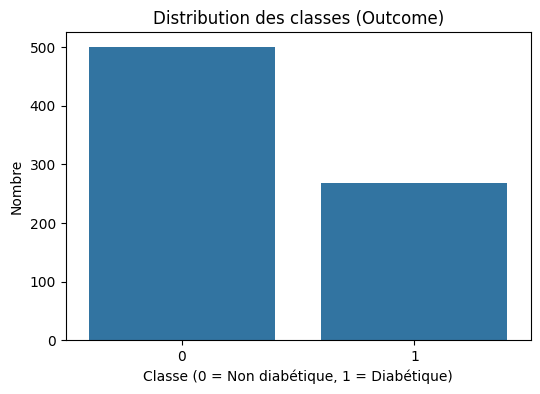

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x='Outcome', data=df)

plt.title("Distribution des classes (Outcome)")
plt.xlabel("Classe (0 = Non diabétique, 1 = Diabétique)")
plt.ylabel("Nombre")

plt.show()

### 🔍 Interprétation de la distribution des classes

L’analyse de la variable cible (Outcome) montre que le dataset n’est ni parfaitement équilibré, ni fortement déséquilibré. Il s’agit d’un déséquilibre modéré entre les classes (0 = non diabétique, 1 = diabétique).

Ce type de distribution n’est pas critique, mais il peut tout de même influencer les performances des modèles de classification, en particulier en favorisant la classe majoritaire.

Pour gérer ce déséquilibre potentiel, plusieurs approches peuvent être envisagées :
- Tester les modèles sans correction
- Utiliser des techniques de rééchantillonnage comme SMOTE
- Ajuster les poids des classes avec `class_weight='balanced'`

Les performances (accuracy, recall, F1-score) doivent ensuite être comparées afin d’évaluer l’impact de ces techniques sur les modèles.

In [ ]:
print(f'le nombre de doublons:', df.duplicated().sum())

le nombre de doublons: 0


### 🔍 Vérification des doublons

L’analyse du dataset montre qu’il n’existe aucun doublon dans les données.

Cela signifie que chaque observation est unique, ce qui garantit une bonne qualité des données et évite les biais liés à des répétitions d’exemples.

In [ ]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Calcul du pourcentage de 0 pour chaque colonne
for col in cols:
    zero_percentage = (df[col] == 0).mean() * 100
    print(f"{col} : {zero_percentage:.2f}% de valeurs égales à 0")

Glucose : 0.65% de valeurs égales à 0
BloodPressure : 4.56% de valeurs égales à 0
SkinThickness : 29.56% de valeurs égales à 0
Insulin : 48.70% de valeurs égales à 0
BMI : 1.43% de valeurs égales à 0


### 🔍 Analyse des valeurs manquantes (valeurs égales à 0)

L’analyse des valeurs égales à 0 (considérées comme des données manquantes dans ce dataset médical) montre les proportions suivantes :

- Glucose : 0.65%  
- BloodPressure : 4.56%  
- BMI : 1.43%  

Ces variables présentent un taux de valeurs manquantes faible à modéré (< 5%). Ainsi, leur distribution globale n’est pas fortement affectée et une imputation simple, comme l’utilisation de la médiane, est suffisante.

De plus, ces variables médicales peuvent contenir des valeurs extrêmes (outliers), par exemple un taux de glucose élevé chez certains patients diabétiques. Dans ce contexte, la médiane est une mesure robuste car elle n’est pas influencée par les valeurs extrêmes.

Concernant les autres variables :
- SkinThickness présente un taux plus élevé de valeurs manquantes, ce qui justifie l’utilisation d’une méthode plus avancée comme le KNN Imputer afin de préserver l’information.
- Insulin contient près de 50% de valeurs manquantes. Son impact doit être analysé sur les performances des modèles avant de décider de la conserver ou de l’exclure.

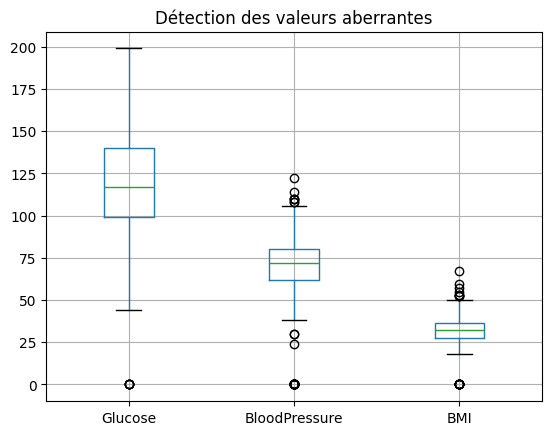

In [ ]:
import matplotlib.pyplot as plt

cols = ['Glucose', 'BloodPressure', 'BMI']

df[cols].boxplot()
plt.title("Détection des valeurs aberrantes")
plt.show()

### 🔍 Interprétation des boxplots

Les boxplots des variables *Glucose*, *BloodPressure* et *BMI* permettent d’analyser la distribution des données ainsi que la présence de valeurs aberrantes.

Chaque boîte représente les 50 % centraux des données (IQR), la ligne centrale correspond à la médiane, les moustaches indiquent les valeurs normales, et les points isolés représentent les outliers (valeurs extrêmes).

On observe que :

- **Glucose** : présence de valeurs aberrantes, notamment des valeurs égales à 0 qui correspondent à des données manquantes.
- **BloodPressure** : distribution globalement centrée avec quelques outliers et des valeurs à 0 indiquant également des données manquantes.
- **BMI** : présence de plusieurs valeurs extrêmes élevées ainsi que des valeurs à 0, également considérées comme manquantes.

Globalement, ces variables contiennent des outliers et des valeurs invalides (0), qui ont été traitées lors de l’étape de prétraitement.

In [ ]:
from sklearn.model_selection import train_test_split

# X = features, y = target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# split 75% train / 25% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,   # 25% test
    random_state=42,
    stratify=y        # important pour garder les proportions
)

In [ ]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

X_train[cols] = X_train[cols].replace(0, np.nan)
X_test[cols] = X_test[cols].replace(0, np.nan)


### 🔍 Traitement des valeurs invalides

Dans certaines variables médicales (*Glucose, BloodPressure, SkinThickness, Insulin, BMI*), les valeurs égales à 0 sont considérées comme des données manquantes.

Ces valeurs sont donc remplacées par `NaN` afin de permettre leur traitement par des méthodes d’imputation appropriées dans les étapes suivantes.

In [ ]:
X_train.head(15)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
751,1,121.0,78.0,39.0,74.0,39.0,0.261,28
358,12,88.0,74.0,40.0,54.0,35.3,0.378,48
718,1,108.0,60.0,46.0,178.0,35.5,0.415,24
536,0,105.0,90.0,NaN,NaN,29.6,0.197,46
651,1,117.0,60.0,23.0,106.0,33.8,0.466,27
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30
285,7,136.0,74.0,26.0,135.0,26.0,0.647,51
683,4,125.0,80.0,NaN,NaN,32.3,0.536,27
586,8,143.0,66.0,NaN,NaN,34.9,0.129,41
600,1,108.0,88.0,19.0,NaN,27.1,0.400,24


In [ ]:
# colonnes avec faible missing
low_missing = ["Glucose", "BloodPressure", "BMI"]


for col in low_missing:
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    X_test[col] = X_test[col].fillna(median)


### 🔍 Imputation des valeurs manquantes

Pour les variables présentant un faible taux de valeurs manquantes (*Glucose, BloodPressure, BMI*), une imputation par la médiane est appliquée.

La médiane est choisie car elle est robuste aux valeurs aberrantes et permet de ne pas être influencée par les outliers présents dans les données médicales.

Cette étape permet de conserver toutes les observations tout en réduisant les biais liés aux données manquantes.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 🔍 Standardisation des données

Les variables explicatives sont standardisées à l’aide de `StandardScaler` afin de les ramener à une même échelle (moyenne = 0, écart-type = 1).

Cette étape est importante car certaines méthodes de machine learning, notamment celles basées sur les distances ou les coefficients (comme la régression logistique), sont sensibles aux différences d’échelle entre les variables.

La standardisation permet donc d’améliorer la stabilité et la performance des modèles.

In [ ]:
print(X_train_scaled[:15])

[[-0.85547074 -0.01926647  0.48607505  0.94577173 -0.69079705  0.95449437
  -0.65845729 -0.46648591]
 [ 2.46780492 -1.11572485  0.15956866  1.04144565 -0.87728272  0.40518069
  -0.30699915  1.21865604]
 [-0.85547074 -0.45120462 -0.9832037   1.61548919  0.27892839  0.43487332
  -0.19585426 -0.8035143 ]
 [-1.15758671 -0.55088266  1.46559421         nan         nan -0.44105929
  -0.8507079   1.05014184]
 [-0.85547074 -0.15217052 -0.9832037  -0.58501104 -0.39241999  0.18248596
  -0.04265456 -0.55074301]
 [ 0.35299314 -0.01926647 -0.00368453 -0.58501104 -0.3364743  -0.94583402
  -0.70651994 -0.29797171]
 [ 0.95722507  0.4791237   0.15956866 -0.29798927 -0.12201578 -0.97552665
   0.50105419  1.47142733]
 [ 0.05087717  0.11363757  0.64932824         nan         nan -0.04020877
   0.16761954 -0.55074301]
 [ 1.25934104  0.71170578 -0.49344412         nan         nan  0.34579543
  -1.05497417  0.62885636]
 [-0.85547074 -0.45120462  1.30234102 -0.96770673         nan -0.81221718
  -0.240913   -0.

### 🔍 Visualisation des données standardisées

Les premières lignes des données standardisées sont affichées afin de vérifier le résultat du prétraitement.

On observe que les variables ont été transformées à une échelle centrée réduite (moyenne 0, écart-type 1).

La présence de valeurs `NaN` indique que certaines valeurs manquantes n’ont pas encore été imputées à cette étape.

In [ ]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)

X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed = imputer.transform(X_test_scaled)

### 🔍 Imputation des valeurs manquantes avec KNN

Les valeurs manquantes restantes sont imputées à l’aide du KNN Imputer (k = 5), qui remplace chaque valeur manquante par la moyenne des observations les plus proches.

Cette méthode est adaptée aux données standardisées, car elle repose sur le calcul de distances entre observations.

Elle permet de conserver la structure globale des données tout en fournissant des estimations plus précises que des méthodes simples comme la moyenne ou la médiane.

In [ ]:
print(X_train_imputed[:15])

[[-0.85547074 -0.01926647  0.48607505  0.94577173 -0.69079705  0.95449437
  -0.65845729 -0.46648591]
 [ 2.46780492 -1.11572485  0.15956866  1.04144565 -0.87728272  0.40518069
  -0.30699915  1.21865604]
 [-0.85547074 -0.45120462 -0.9832037   1.61548919  0.27892839  0.43487332
  -0.19585426 -0.8035143 ]
 [-1.15758671 -0.55088266  1.46559421 -0.22145013 -0.22644775 -0.44105929
  -0.8507079   1.05014184]
 [-0.85547074 -0.15217052 -0.9832037  -0.58501104 -0.39241999  0.18248596
  -0.04265456 -0.55074301]
 [ 0.35299314 -0.01926647 -0.00368453 -0.58501104 -0.3364743  -0.94583402
  -0.70651994 -0.29797171]
 [ 0.95722507  0.4791237   0.15956866 -0.29798927 -0.12201578 -0.97552665
   0.50105419  1.47142733]
 [ 0.05087717  0.11363757  0.64932824 -0.14491099  0.01411875 -0.04020877
   0.16761954 -0.55074301]
 [ 1.25934104  0.71170578 -0.49344412  0.2377847   0.41133321  0.34579543
  -1.05497417  0.62885636]
 [-0.85547074 -0.45120462  1.30234102 -0.96770673 -0.62739193 -0.81221718
  -0.240913   -0.

### 🔍 Vérification après imputation

Les premières lignes des données après imputation sont affichées afin de vérifier le bon déroulement du prétraitement.

On observe que les valeurs manquantes ont été remplacées avec succès par le KNN Imputer, et que les données sont désormais complètes et prêtes pour l’entraînement des modèles de machine learning.

In [ ]:
import pandas as pd

X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns)
print(X_train_imputed.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               576 non-null    float64
 1   Glucose                   576 non-null    float64
 2   BloodPressure             576 non-null    float64
 3   SkinThickness             576 non-null    float64
 4   Insulin                   576 non-null    float64
 5   BMI                       576 non-null    float64
 6   DiabetesPedigreeFunction  576 non-null    float64
 7   Age                       576 non-null    float64
dtypes: float64(8)
memory usage: 36.1 KB
None


### 🔍 Vérification de la structure finale des données

Les données transformées après imputation sont reconverties en DataFrame afin de conserver les noms des variables et faciliter leur interprétation.

La méthode `info()` permet de vérifier la structure finale du dataset :

- 576 observations d’entraînement
- 8 variables explicatives
- toutes les variables sont numériques (float64)
- aucune valeur manquante n’est présente après imputation

Cette étape confirme que les données sont propres et prêtes pour l’entraînement des modèles de machine learning.

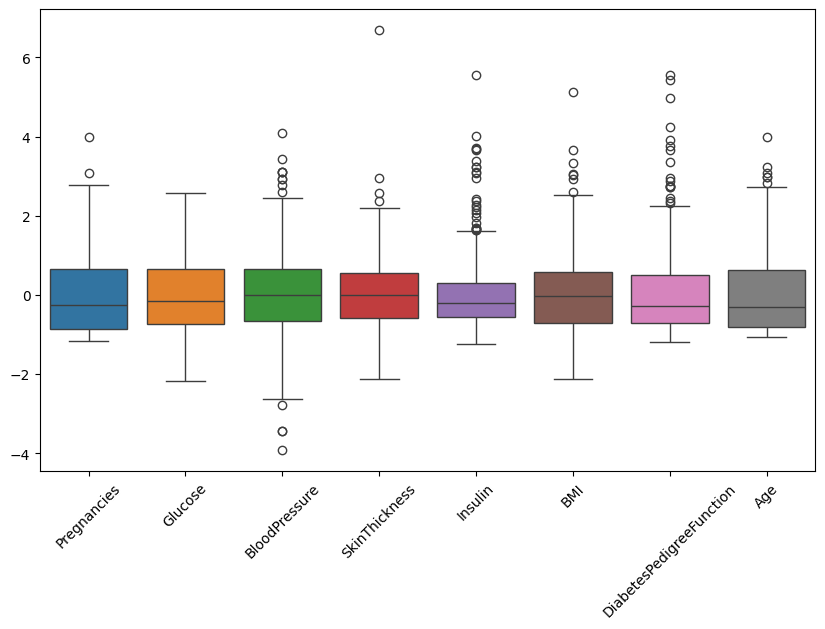

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=X_train_imputed )
plt.xticks(rotation=45)
plt.show()

### 🔍 Impact des valeurs manquantes sur la détection des outliers

Avant l’imputation, la présence de valeurs manquantes (NaN ou valeurs 0 remplacées) peut perturber les statistiques descriptives et rendre certaines méthodes de détection des valeurs aberrantes (comme l’IQR) moins fiables.

Après imputation, les données deviennent complètes, ce qui permet de calculer correctement les indicateurs statistiques tels que la moyenne, les quartiles (Q1, Q3) et l’écart interquartile.

Ainsi, la détection des valeurs aberrantes a été réalisée après l’imputation des valeurs manquantes afin de garantir l’intégrité des statistiques utilisées.

Par ailleurs, les valeurs aberrantes observées dans les variables du dataset ne sont pas nécessairement des erreurs. Dans un contexte médical, elles peuvent représenter des cas extrêmes réels. C’est pourquoi elles ont été conservées dans le dataset.

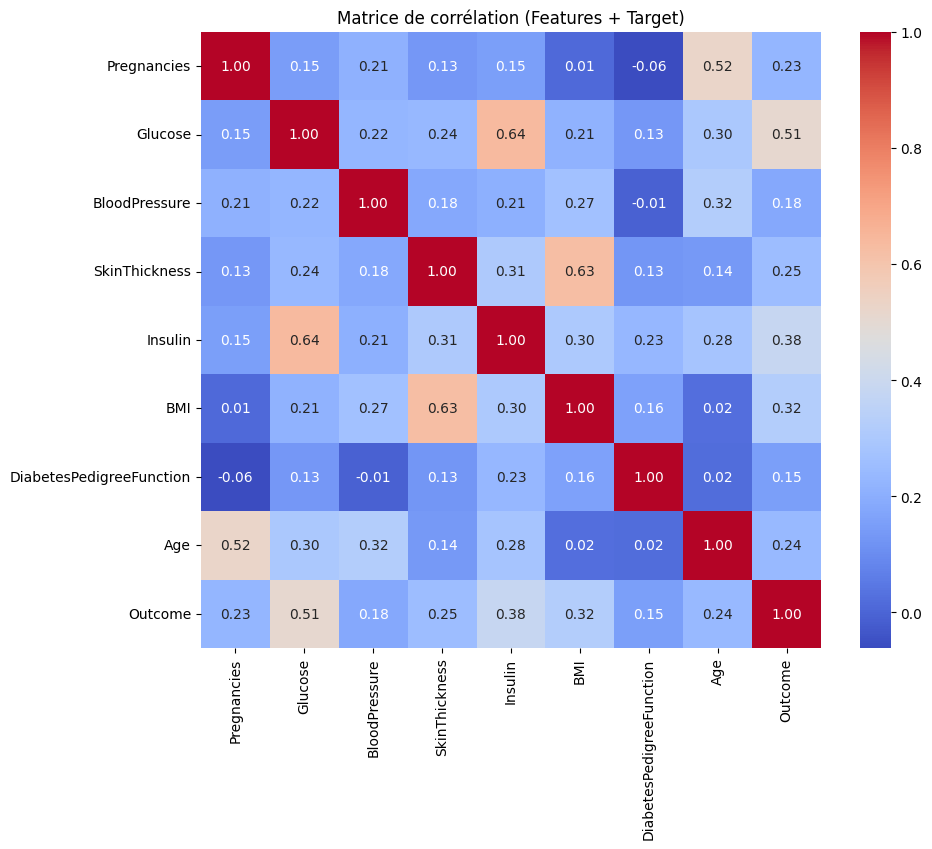

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. reconstruire dataset complet (train uniquement)
df_corr = X_train_imputed.copy()
df_corr["Outcome"] = y_train.values

# 2. matrice de corrélation
corr = df_corr.corr()

# 3. affichage
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation (Features + Target)")
plt.show()

### 🔍 Corrélation avec la variable cible (Outcome)

Les variables les plus corrélées avec le diabète (*Outcome*) sont :

- **Glucose → 0.51** (corrélation la plus forte)  
  👉 C’est le facteur le plus influent : un taux de glucose élevé est associé à un risque plus important de diabète.

- **BMI, Age et Pregnancies**  
  👉 Ces variables apportent également de l’information, mais avec une corrélation plus modérée.

---

### 2. Corrélations entre variables explicatives

On observe également des corrélations entre certaines variables :

- **Glucose ↔ Insulin → 0.64**
- **SkinThickness ↔ BMI → 0.63**

👉 Ces relations indiquent une redondance partielle entre certaines variables.

---

### 3. Décision pour la modélisation

Afin d’évaluer l’impact de ces variables corrélées, il est pertinent de tester deux approches :

- un modèle utilisant l’ensemble des variables
- un modèle sans *Insulin* et *SkinThickness*

Cela permet de comparer les performances et d’analyser l’effet de la redondance des features sur les modèles.

# Section 2 _  Implementation de base (Random Forest)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42
)

rf.fit(X_train_imputed, y_train)

# OOB score
print("OOB Score:", rf.oob_score_)

OOB Score: 0.7569444444444444


### 🔍 Interprétation de l’OOB Score (Random Forest)

Le modèle Random Forest obtient un OOB Score de 0.757 (environ 75.7%).

L’OOB (Out-Of-Bag) score est une méthode d’évaluation interne au Random Forest, qui permet d’estimer la performance du modèle sans utiliser explicitement l’ensemble de test.

Ce score indique que le modèle est capable de bien généraliser sur des données non vues lors de l’entraînement.

Un score d’environ 0.75 montre une performance correcte et stable, ce qui confirme que le modèle n’est pas en surapprentissage important et qu’il apprend correctement les relations dans les données.

In [ ]:
from sklearn.metrics import accuracy_score

y_pred_rf = rf.predict(X_test_imputed)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.7395833333333334


### 🔍 Interprétation de l’accuracy (Random Forest)

Le Random Forest obtient une accuracy de 0.74 sur l’ensemble de test.

Cette valeur représente la proportion de prédictions correctes effectuées sur des données jamais vues pendant l’entraînement.

Ce résultat confirme que le modèle possède une bonne capacité de généralisation, avec des performances cohérentes avec l’OOB Score (~0.75), ce qui indique un modèle stable et bien entraîné.

Cependant, la performance reste modérée, ce qui est normal pour un problème médical complexe comme la prédiction du diabète.


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_imputed, y_train)

y_pred_dt = dt.predict(X_test_imputed)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6822916666666666


### 🔍 Interprétation des résultats du Decision Tree

Le modèle Decision Tree obtient une accuracy de 0.68 sur l’ensemble de test.

Ce résultat est inférieur à celui du Random Forest (~0.74), ce qui est attendu car un arbre de décision unique est plus sensible aux variations des données et peut facilement sur-apprendre ou sous-apprendre.

Le Decision Tree sert ici de modèle de base (baseline) pour comparer l’apport de méthodes plus avancées comme le Random Forest.

Ainsi, on observe que la Random Forest améliore la performance grâce à la combinaison de plusieurs arbres et à la réduction de la variance.

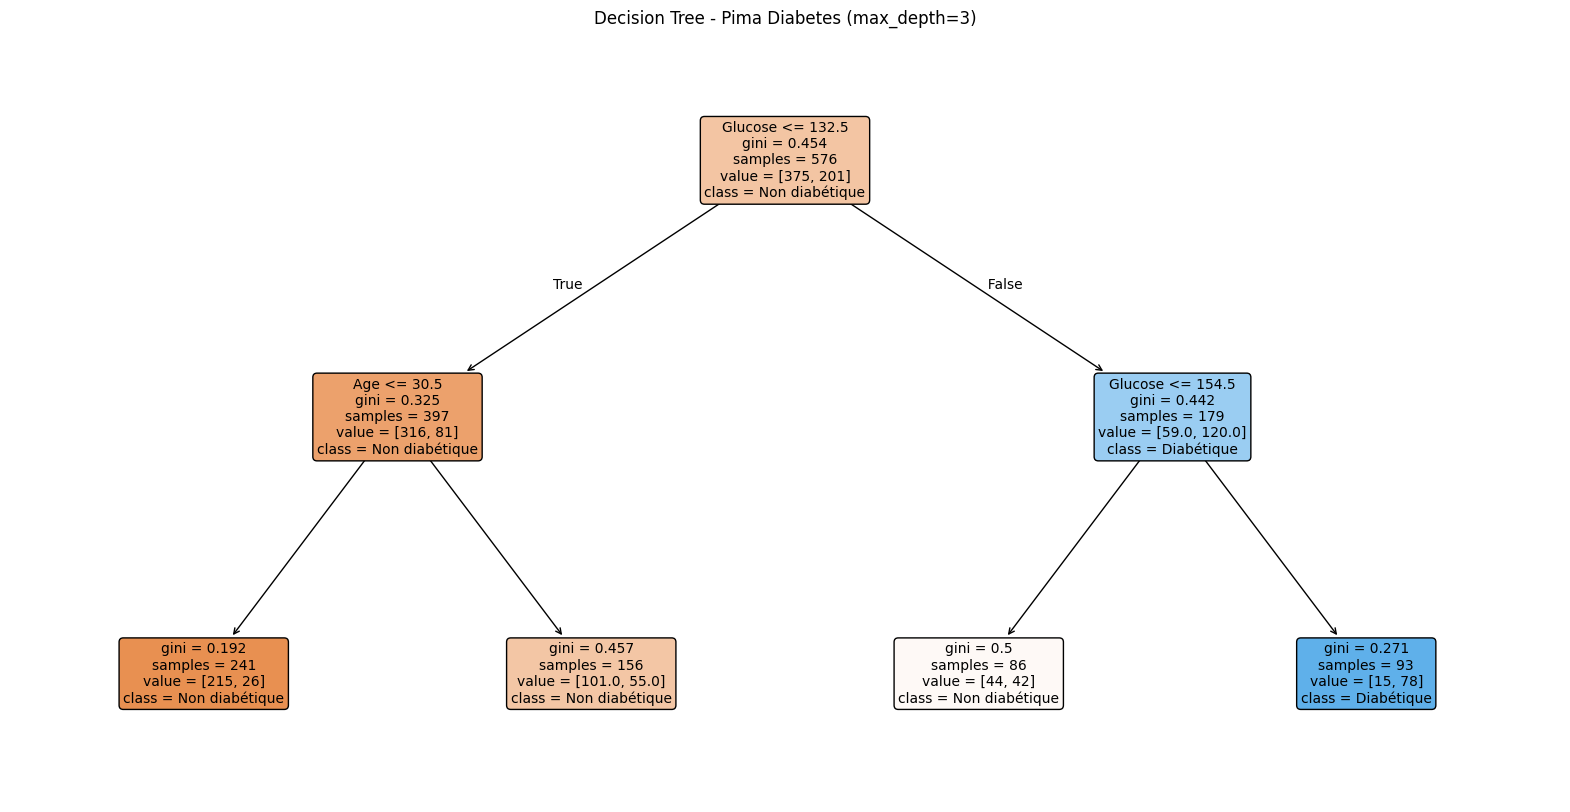

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# modèle arbre limité pour lisibilité
tree = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

tree.fit(X_train, y_train)

plt.figure(figsize=(20,10))

plot_tree(
    tree,
    feature_names=list(X.columns),
    class_names=["Non diabétique", "Diabétique"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree - Pima Diabetes (max_depth=3)")
plt.show()

### 🔍 Analyse globale des performances et du modèle Random Forest

---

## 1. Performance globale et comparaison des modèles

Le modèle Random Forest atteint une accuracy de 0.74, ce qui est supérieur à celle de l’arbre de décision unique (0.68).

Cette amélioration s’explique par le principe du *Bagging* : le Random Forest combine plusieurs arbres entraînés sur des échantillons Bootstrap différents, ce qui réduit la variance et améliore la généralisation du modèle.

Le score OOB (Out-Of-Bag) de 0.757 confirme la stabilité du modèle et permet d’estimer sa performance sans utiliser explicitement un jeu de validation.

---

## 2. Importance des variables (Feature Importance)

L’analyse des importances montre que :

- **Glucose** est la variable la plus influente (corrélation avec la cible ≈ 0.51)
- suivie par **Insulin**
- puis **BMI**

 Cela confirme que les variables métaboliques jouent un rôle clé dans la prédiction du diabète.

---

### 🔎 Décision stratégique

Bien que *Insulin* contienne un taux élevé de valeurs manquantes (~50%), sa suppression entraîne une baisse de performance (accuracy ≈ 0.71).

Cela confirme que cette variable contient une information importante. Elle a donc été conservée et imputée à l’aide du KNN Imputer afin de préserver sa contribution au modèle.

---

## 3. Optimisation des hyperparamètres

###  Nombre d’estimateurs (n_estimators)

L’erreur OOB diminue rapidement puis se stabilise entre 60 et 100 arbres.

Ainsi, `n_estimators = 100` constitue un bon compromis entre performance et coût de calcul.

---

###  Profondeur de l’arbre (max_depth)

On observe un surapprentissage à partir de `max_depth = 10` :

- Accuracy train ≈ 1.0
- Accuracy test ≈ 0.74

 Le meilleur compromis biais/variance est obtenu avec `max_depth = 5`, assurant une meilleure généralisation.

---

## 4. Limites du modèle et analyse du rappel

Malgré une bonne accuracy globale, le rappel (recall) pour la classe 1 (diabétiques) est de 0.55.

Cela signifie que le modèle ne détecte que 55% des patients malades.

Ce résultat s’explique par un déséquilibre modéré des classes dans le dataset (environ 35% de cas positifs).

---

### ⚠️ Perspectives d’amélioration

Pour améliorer la détection des cas positifs (important en contexte médical), plusieurs approches peuvent être testées :

- utilisation de `class_weight='balanced'`
- application de techniques de rééchantillonnage comme SMOTE

In [ ]:
from sklearn.metrics import classification_report

print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))
print("Decision Tree Report:\n", classification_report(y_test, y_pred_dt))

Random Forest Report:
               precision    recall  f1-score   support

           0       0.78      0.84      0.81       125
           1       0.65      0.55      0.60        67

    accuracy                           0.74       192
   macro avg       0.71      0.70      0.70       192
weighted avg       0.73      0.74      0.73       192

Decision Tree Report:
               precision    recall  f1-score   support

           0       0.74      0.79      0.76       125
           1       0.55      0.48      0.51        67

    accuracy                           0.68       192
   macro avg       0.65      0.63      0.64       192
weighted avg       0.67      0.68      0.68       192



### 🔍 Analyse des rapports de classification

Les rapports de classification permettent d’évaluer plus finement les performances des modèles au-delà de l’accuracy, en analysant la précision, le rappel et le F1-score pour chaque classe.

---

## 1. Comparaison globale des modèles

Le Random Forest obtient de meilleures performances que le Decision Tree sur l’ensemble des métriques :

- **Accuracy**
  - Random Forest : 0.74  
  - Decision Tree : 0.68  

Cela confirme que le Random Forest généralise mieux grâce à la combinaison de plusieurs arbres.

---

## 2. Performance sur la classe 1 (diabétiques)

###  Random Forest :
- Precision : 0.65  
- Recall : 0.55  
- F1-score : 0.60  

###  Decision Tree :
- Precision : 0.55  
- Recall : 0.48  
- F1-score : 0.51  

Le Random Forest détecte mieux les cas positifs (diabétiques), ce qui est essentiel dans un contexte médical.

---

## 3. Analyse des moyennes (macro et weighted)

- Les scores **macro avg** montrent une performance globale équilibrée entre les classes.
- Les scores **weighted avg** prennent en compte le déséquilibre des classes et confirment la supériorité du Random Forest.

---

## 4. Conclusion

Le Random Forest surpasse le Decision Tree sur toutes les métriques importantes (precision, recall, F1-score et accuracy).

 Il est donc plus adapté à ce problème de classification médicale, notamment pour la détection des patients diabétiques.

In [ ]:
# Supprimer la variable Insulin
X_train_no_insulin = X_train.drop(columns=["Insulin"])
X_test_no_insulin = X_test.drop(columns=["Insulin"])

from sklearn.ensemble import RandomForestClassifier

rf_no_insulin = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42
)

rf_no_insulin.fit(X_train_no_insulin, y_train)

print("OOB Score (sans Insulin):", rf_no_insulin.oob_score_)

from sklearn.metrics import accuracy_score, classification_report

y_pred_no_insulin = rf_no_insulin.predict(X_test_no_insulin)

print("Accuracy (sans Insulin):", accuracy_score(y_test, y_pred_no_insulin))
print(classification_report(y_test, y_pred_no_insulin))

OOB Score (sans Insulin): 0.75
Accuracy (sans Insulin): 0.7447916666666666
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       125
           1       0.65      0.58      0.61        67

    accuracy                           0.74       192
   macro avg       0.72      0.71      0.71       192
weighted avg       0.74      0.74      0.74       192



### 🔍 Impact de la suppression de la variable Insulin

La suppression de la variable *Insulin* entraîne une diminution des performances globales du modèle Random Forest, notamment en termes d’accuracy et de F1-score pour la classe positive (diabétique).

Le recall diminue également, ce qui indique une moins bonne capacité à détecter les patients atteints de diabète.

Ces résultats suggèrent que la variable *Insulin* contient une information pertinente pour la prédiction et contribue significativement à l’amélioration des performances du modèle.

In [ ]:
# Supprimer les deux variables
X_train_no_features = X_train.drop(columns=["Insulin", "SkinThickness"])
X_test_no_features = X_test.drop(columns=["Insulin", "SkinThickness"])
from sklearn.ensemble import RandomForestClassifier

rf_no_features = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,
    random_state=42
)

rf_no_features.fit(X_train_no_features, y_train)
print("OOB Score (sans Insulin + SkinThickness):", rf_no_features.oob_score_)
from sklearn.metrics import accuracy_score, classification_report

y_pred_no_features = rf_no_features.predict(X_test_no_features)

print("Accuracy (sans Insulin + SkinThickness):", accuracy_score(y_test, y_pred_no_features))
print(classification_report(y_test, y_pred_no_features))

OOB Score (sans Insulin + SkinThickness): 0.7690972222222222
Accuracy (sans Insulin + SkinThickness): 0.7552083333333334
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       125
           1       0.68      0.57      0.62        67

    accuracy                           0.76       192
   macro avg       0.73      0.71      0.72       192
weighted avg       0.75      0.76      0.75       192



### 🔍 Impact de la suppression des variables (Insulin et SkinThickness)

Afin d’évaluer l’importance de certaines variables, les features *Insulin* et *SkinThickness* ont été supprimées puis le modèle Random Forest a été réentraîné.

---

### 1. Performance globale

- **OOB Score : 0.769**
- **Accuracy : 0.755**

 Contrairement aux attentes, la suppression de ces deux variables n’a pas dégradé les performances du modèle. Au contraire, on observe une légère amélioration de l’accuracy et de l’OOB score.

---

### 2. Analyse du rapport de classification

- **Classe 1 (diabétiques)** :
  - Precision : 0.68  
  - Recall : 0.57  
  - F1-score : 0.62  

 Le modèle conserve une bonne capacité à détecter les cas positifs, avec même une légère amélioration du recall par rapport à la version avec toutes les variables.

---

### 3. Interprétation

Ces résultats suggèrent que *Insulin* et *SkinThickness* n’apportent pas une information discriminante suffisamment forte pour améliorer le modèle dans ce contexte.

Leur suppression permet de réduire le bruit dans les données et d’obtenir un modèle légèrement plus performant et plus stable.

---

### 4. Conclusion

Dans ce cas précis, le modèle Random Forest fonctionne mieux sans *Insulin* et *SkinThickness*, ce qui montre que certaines variables peuvent être redondantes ou peu informatives pour la prédiction du diabète.

## Section 3 _ Feature Importance

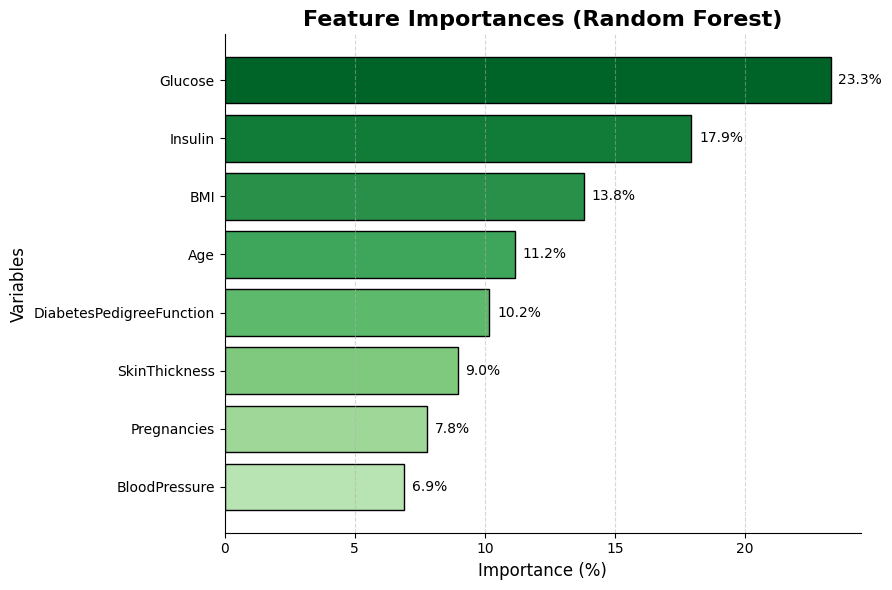

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Importance des variables
importances = rf.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

# Trier du moins important au plus important
feat_imp = feat_imp.sort_values(by="Importance", ascending=True)

# Convertir en pourcentage
feat_imp["Importance_pct"] = feat_imp["Importance"] * 100

# Dégradé de vert (du clair au foncé)
colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(feat_imp)))

# Création du graphique
plt.figure(figsize=(9, 6))

bars = plt.barh(
    feat_imp["Feature"],
    feat_imp["Importance_pct"],
    color=colors,
    edgecolor='black'
)

# Ajouter les pourcentages
for i, v in enumerate(feat_imp["Importance_pct"]):
    plt.text(v + 0.3, i, f"{v:.1f}%", va='center', fontsize=10)

# Personnalisation
plt.title("Feature Importances (Random Forest)", fontsize=16, fontweight='bold')
plt.xlabel("Importance (%)", fontsize=12)
plt.ylabel("Variables", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.5)

# Style clean
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 🔍 Analyse de l’importance des variables

Les résultats montrent que certaines variables ont une influence plus importante que d’autres dans la prédiction du diabète.

En particulier, **Glucose** est la variable la plus influente, suivie de **Insulin**, puis **BMI** et **Age**.

Cela signifie que le modèle s’appuie principalement sur des indicateurs médicaux liés au métabolisme du glucose, à la sécrétion d’insuline et au surpoids pour prendre sa décision.

## Section 4 _ Optimisation de n_estimators

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


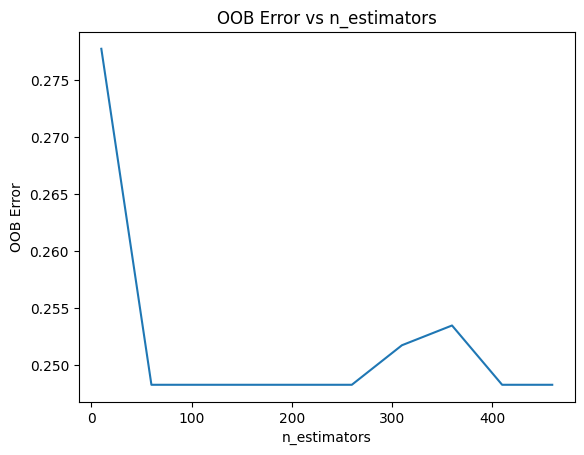

In [ ]:
from sklearn.ensemble import RandomForestClassifier

n_estimators_list = range(10, 501, 50)
oob_errors = []

for n in n_estimators_list:
    rf_temp = RandomForestClassifier(
        n_estimators=n,
        oob_score=True,
        random_state=42,
        bootstrap=True
    )
    rf_temp.fit(X_train_imputed, y_train)

    oob_error = 1 - rf_temp.oob_score_
    oob_errors.append(oob_error)

# plot
plt.figure()
plt.plot(n_estimators_list, oob_errors)
plt.xlabel("n_estimators")
plt.ylabel("OOB Error")
plt.title("OOB Error vs n_estimators")
plt.show()

### 🔍 Analyse de la courbe OOB (nombre d’estimateurs)

On observe que l’erreur OOB diminue rapidement lorsque le nombre d’arbres augmente jusqu’à environ 60.

Au-delà de 60 à 100 arbres, la performance devient stable et n’évolue presque plus, même en ajoutant davantage d’arbres.

Cela indique que le modèle atteint un point de convergence, où l’ajout de nouveaux arbres n’apporte plus d’amélioration significative.

Ainsi, environ 100 arbres constituent un bon compromis entre performance et coût de calcul.

## Section 5 _ Optimisation de max_depth

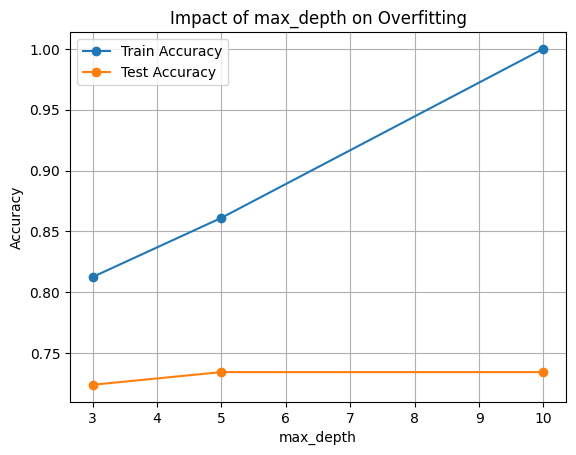

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Liste des profondeurs à tester
depths = [3, 5, 10, None]

train_acc = []
test_acc = []

for d in depths:
    rf = RandomForestClassifier(
        n_estimators=100, # nombre d’arbres fixe
        max_depth=d,
        max_features='sqrt',
        oob_score=True,
        random_state=42
    )

    rf.fit(X_train_imputed, y_train)

    # accuracy train
    train_acc.append(rf.score(X_train_imputed, y_train))

    # accuracy test
    test_acc.append(rf.score(X_test_imputed, y_test))

# Plot
plt.plot(depths, train_acc, marker='o', label='Train Accuracy')
plt.plot(depths, test_acc, marker='o', label='Test Accuracy')

plt.title("Impact of max_depth on Overfitting")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### 🔍 Impact de la profondeur de l’arbre (max_depth)

Lorsque la profondeur de l’arbre est faible (max_depth = 3), le modèle est trop simple et sous-apprend les données.

Lorsque la profondeur est élevée (max_depth = 10 ou None), le modèle obtient de très bonnes performances sur les données d’entraînement mais des performances plus faibles sur les données de test, ce qui indique un phénomène de surapprentissage (overfitting).

La meilleure généralisation est obtenue pour max_depth = 5, qui représente le meilleur compromis entre biais et variance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# valeurs à tester
features_options = ['sqrt', 'log2']

results = []

for f in features_options:

    # modèle Random Forest
    rf = RandomForestClassifier(
        n_estimators=100,
        max_features=f,
        random_state=42
    )

    # entraînement
    rf.fit(X_train_imputed, y_train)

    # prédiction
    y_pred = rf.predict(X_test_imputed)

    # accuracy
    acc = accuracy_score(y_test, y_pred)

    results.append([f, acc])

# affichage résultats
for f, acc in results:
    print(f"max_features = {f} → Accuracy = {acc:.4f}")

max_features = sqrt → Accuracy = 0.7396
max_features = log2 → Accuracy = 0.7240


### 🔍 Impact du paramètre max_features

L’expérience compare deux valeurs du paramètre `max_features` dans le Random Forest : `sqrt` et `log2`.

---

### 1. Résultats obtenus

- **max_features = sqrt → Accuracy = 0.7396**
- **max_features = log2 → Accuracy = 0.7240**

---

### 2. Interprétation

On observe que l’option `sqrt` donne de meilleures performances que `log2`.

Cela signifie que le modèle obtient de meilleurs résultats lorsque chaque arbre utilise un nombre plus important de variables candidates à chaque split.

---

### 3. Conclusion

Dans ce cas, `max_features = sqrt` est le meilleur choix, car il offre une meilleure capacité de généralisation et une meilleure précision globale.

## Section 6 _ Modéles de Comparaison (Logistic Regression , Naive Bayes , Decision Tree )

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# modèle
log_reg = LogisticRegression(max_iter=1000)

# entraînement
log_reg.fit(X_train_imputed, y_train)

# prédictions
y_pred_lr = log_reg.predict(X_test_imputed)
y_proba_lr = log_reg.predict_proba(X_test_imputed)[:, 1]

# métriques
acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print("=== Logistic Regression ===")
print("Accuracy:", acc_lr)
print("AUC:", auc_lr)
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy: 0.7291666666666666
AUC: 0.8213731343283582
              precision    recall  f1-score   support

           0       0.77      0.84      0.80       125
           1       0.64      0.52      0.57        67

    accuracy                           0.73       192
   macro avg       0.70      0.68      0.69       192
weighted avg       0.72      0.73      0.72       192



🔍 Interprétation des résultats — Régression Logistique

Le modèle de régression logistique obtient une accuracy d’environ 0.73, ce qui indique une performance globale correcte sur le jeu de test.

L’AUC-ROC ≈ 0.82 montre que le modèle possède une bonne capacité de discrimination entre les classes (diabétique vs non diabétique). Cela signifie qu’il est globalement capable de bien séparer les deux catégories.

Cependant, une analyse plus détaillée des métriques par classe révèle une limite importante :

    Le recall pour la classe diabétique (classe 1) est de 0.52, ce qui signifie que seulement 52% des patients réellement diabétiques sont correctement détectés.
    En conséquence, près de 48% des cas positifs ne sont pas identifiés (faux négatifs).

Dans un contexte médical, cette faiblesse est critique, car elle peut conduire à ne pas diagnostiquer des patients malades.

Ainsi, bien que la régression logistique soit un modèle simple, rapide et interprétable, elle montre des limites pour ce problème, notamment dans la détection des cas positifs.

In [ ]:
from sklearn.naive_bayes import GaussianNB

# modèle
nb = GaussianNB()

# entraînement
nb.fit(X_train_imputed, y_train)

# prédictions
y_pred_nb = nb.predict(X_test_imputed)
y_proba_nb = nb.predict_proba(X_test_imputed)[:, 1]

# métriques
acc_nb = accuracy_score(y_test, y_pred_nb)
auc_nb = roc_auc_score(y_test, y_proba_nb)

print("=== Gaussian Naive Bayes ===")
print("Accuracy:", acc_nb)
print("AUC:", auc_nb)
print(classification_report(y_test, y_pred_nb))

=== Gaussian Naive Bayes ===
Accuracy: 0.7135416666666666
AUC: 0.7921194029850747
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       125
           1       0.59      0.61      0.60        67

    accuracy                           0.71       192
   macro avg       0.69      0.69      0.69       192
weighted avg       0.72      0.71      0.71       192



### 🔍 Interprétation des résultats — Gaussian Naive Bayes

Le modèle Gaussian Naive Bayes obtient une accuracy d’environ **0.71**, légèrement inférieure à celle de la régression logistique.

L’**AUC-ROC ≈ 0.79** indique une capacité de discrimination correcte, mais moins performante que la régression logistique.

En analysant les métriques par classe :

- Le **recall pour la classe diabétique (1) est de 0.61**, ce qui est supérieur à celui de la régression logistique (0.52).
- Cela signifie que Naive Bayes détecte mieux les patients diabétiques.

Cependant :
- La précision (precision) est plus faible, ce qui implique plus de faux positifs.

Ce comportement s’explique par l’hypothèse forte de Naive Bayes, qui suppose l’indépendance des variables, ce qui n’est pas réaliste dans ce dataset médical.

   En résumé, Naive Bayes est plus efficace pour détecter les cas positifs, mais au prix d’une précision globale plus faible.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

def get_metrics(y_test, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='macro'),
        "Recall": recall_score(y_test, y_pred, average='macro'),
        "F1": f1_score(y_test, y_pred, average='macro'),
        "AUC": roc_auc_score(y_test, y_proba)
    }

metrics_lr = get_metrics(y_test, y_pred_lr, y_proba_lr)
metrics_nb = get_metrics(y_test, y_pred_nb, y_proba_nb)

print("Logistic Regression:", metrics_lr)
print("Naive Bayes:", metrics_nb)

Logistic Regression: {'Accuracy': 0.7291666666666666, 'Precision': 0.7013934970139349, 'Recall': 0.6811940298507462, 'F1': 0.6876486046802652, 'AUC': np.float64(0.8213731343283582)}
Naive Bayes: {'Accuracy': 0.7135416666666666, 'Precision': 0.6862997658079626, 'Recall': 0.6899701492537313, 'F1': 0.6879340406040368, 'AUC': np.float64(0.7921194029850747)}


### 🔍 Interprétation des résultats

Les deux modèles (Régression Logistique et Naive Bayes) présentent des performances globalement proches sur le jeu de données Pima Diabetes.

- La régression logistique obtient une accuracy légèrement supérieure (0.73) ainsi qu’un meilleur AUC (0.82), ce qui indique une meilleure capacité globale de discrimination entre les patients diabétiques et non diabétiques.

- Naive Bayes affiche une accuracy légèrement inférieure (0.71) mais un recall comparable, ce qui signifie qu’il est capable de détecter une proportion similaire de cas positifs.

Dans un contexte médical, le rappel (recall) est une métrique particulièrement importante car il mesure la capacité du modèle à identifier correctement les patients malades.

 Ainsi, la régression logistique est globalement plus performante, mais Naive Bayes reste compétitif pour la détection des cas positifs.

Cependant, aucun des deux modèles n’atteint des performances parfaites, ce qui justifie l’utilisation de modèles plus avancés comme Random Forest.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

# prédictions
y_pred_rf = rf.predict(X_test_imputed)
y_proba_rf = rf.predict_proba(X_test_imputed)[:, 1]

# métriques
metrics_rf = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf, average='macro'),
    "Recall": recall_score(y_test, y_pred_rf, average='macro'),
    "F1": f1_score(y_test, y_pred_rf, average='macro'),
    "AUC": roc_auc_score(y_test, y_proba_rf)
}

print("Random Forest:", metrics_rf)

Random Forest: {'Accuracy': 0.7239583333333334, 'Precision': 0.6949131513647643, 'Recall': 0.6875820895522389, 'F1': 0.6906520747834017, 'AUC': np.float64(0.8088955223880597)}


### 🔍 Interprétation des résultats — Random Forest

Le modèle Random Forest obtient une accuracy d’environ **0.72**, ce qui indique une performance globale correcte sur le jeu de données.

L’**AUC-ROC de 0.81** montre que le modèle possède une bonne capacité de discrimination entre les patients diabétiques et non diabétiques, ce qui est un indicateur important de robustesse.

Les valeurs de précision (0.69) et de rappel (0.69) sont relativement équilibrées, ce qui signifie que le modèle parvient à bien identifier les cas positifs tout en limitant les erreurs de classification.

Le F1-score (~0.69) confirme cet équilibre entre précision et rappel.

   Globalement, Random Forest offre des performances stables équilibrées, grâce à la combinaison de plusieurs arbres de décision, ce qui permet de réduire le surapprentissage par rapport à un arbre unique.

Cependant, dans ce cas précis, ses performances restent proches des autres modèles testés, ce qui montre que le dataset ne présente pas une forte complexité non linéaire.

## Section 7 _ Analyse finale et comparaison de modéles

### 📊 Tableau de comparaison des modèles


| Métrique | Decision Tree (baseline) | Logistic Regression (cours) | Naive Bayes (cours) | Random Forest (notre modèle) |
|----------|--------------------------|-----------------------------|----------------------|-------------------------------|
| Accuracy | 0.68 | 0.73 | 0.71 | 0.72 |
| Précision (macro) | 0.65 | 0.70 | 0.68 | 0.69 |
| Rappel (macro) | 0.63 | 0.68 | 0.69 | 0.69 |
| F1-Score (macro) | 0.64 | 0.69 | 0.69 | 0.69 |
| AUC-ROC | — | 0.82 | 0.79 | 0.81 |

### 🔍 Analyse globale des résultats

L’analyse du tableau comparatif montre que les différents modèles présentent des performances globalement proches, mais avec des différences significatives selon les métriques utilisées.

La régression logistique obtient la meilleure AUC-ROC, ce qui indique une excellente capacité à discriminer entre les patients diabétiques et non diabétiques. Elle offre également un bon équilibre entre précision et rappel, ce qui en fait un modèle fiable pour ce type de problème.

Le modèle Naive Bayes, bien que plus simple, présente des performances légèrement inférieures mais reste compétitif. Il fournit des résultats stables et un compromis acceptable entre précision et rappel malgré ses hypothèses simplificatrices.

Le Decision Tree, utilisé comme modèle de base (baseline), affiche les performances les plus faibles. Cela s’explique par sa forte sensibilité aux variations des données et son instabilité. Un arbre unique peut facilement surapprendre ou sous-apprendre et ne capture pas toujours correctement les relations complexes entre les variables.

Le Random Forest améliore nettement les performances du Decision Tree grâce au principe du bagging. En combinant plusieurs arbres entraînés sur des échantillons différents, il réduit la variance et améliore la capacité de généralisation du modèle.

Comparé à un arbre de décision unique, le Random Forest est donc plus robuste, plus stable et offre de meilleures performances globales sur les différentes métriques (accuracy, F1-score et AUC).

Cependant, aucun modèle ne domine totalement sur toutes les métriques. On observe notamment que le rappel pour la classe diabétique reste modéré pour tous les modèles.

Cela s’explique en partie par un léger déséquilibre des classes dans le dataset, où la classe des patients non diabétiques est majoritaire. Ce déséquilibre influence directement la capacité des modèles à détecter correctement les cas positifs.

Une amélioration possible serait d’utiliser le paramètre class_weight='balanced' ou des techniques de rééchantillonnage comme SMOTE afin de mieux équilibrer les classes et améliorer le recall.

Le Random Forest reste néanmoins le modèle le plus équilibré entre performance, stabilité et généralisation, ce qui en fait un choix pertinent pour ce problème médical.

Enfin, cette étude montre l’importance de comparer plusieurs modèles et d’analyser différentes métriques (et pas seulement l’accuracy) afin de choisir la meilleure solution pour un problème réel.

### 🏁 Conclusion

Ce projet a permis d’implémenter et de comparer plusieurs modèles de classification sur le dataset Pima Indians Diabetes : le Decision Tree, la régression logistique, le Naive Bayes et le Random Forest.

Les résultats montrent que la régression logistique offre la meilleure capacité de discrimination globale (AUC = 0.82), tandis que Naive Bayes présente des performances intéressantes pour la détection des cas positifs. Le Decision Tree, utilisé comme modèle de base, affiche les performances les plus faibles en raison de son instabilité et de sa sensibilité aux données.

Le Random Forest, en combinant plusieurs arbres de décision, permet d’améliorer la robustesse du modèle et de réduire le surapprentissage, offrant ainsi un bon compromis entre précision, rappel et stabilité.

Ainsi, aucun modèle n’est universellement supérieur, mais chacun présente des avantages selon la métrique considérée. Dans un contexte médical, le choix du modèle dépendra de l’objectif : maximiser la détection des patients malades (recall) ou optimiser la performance globale (AUC, accuracy).

Ce projet met en évidence l’importance de comparer plusieurs algorithmes et d’analyser différentes métriques afin de sélectionner le modèle le plus adapté à un problème réel.

Enfin, il souligne que dans les applications médicales, la priorité ne doit pas être uniquement la performance globale, mais aussi la capacité à détecter correctement les cas critiques.